In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
df = pd.read_csv("./data/daily_sales_features.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,daily_sales,day_of_week,day,month,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7
0,2011-01-13,20624.64,3,13,1,0,24693.78,32634.47,45418.33,58960.79,33650.078571,28349.940714,17209.499406
1,2011-01-14,47576.90,4,14,1,0,20624.64,40382.85,7534.91,47748.38,31934.388571,26578.962857,17911.945097
2,2011-01-16,7242.06,6,16,1,1,47576.90,28836.59,26789.13,46943.71,32962.110000,29439.105000,18667.908501
3,2011-01-17,29333.02,0,17,1,0,7242.06,15778.20,47304.09,31774.95,29877.177143,28042.885714,21090.393660
4,2011-01-18,95978.05,1,18,1,0,29333.02,24569.07,6199.97,54830.46,31813.580000,26759.237857,20182.895344


In [3]:
features = [
    "day_of_week",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7"
]

X = df[features]
y = df["daily_sales"]

In [4]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [5]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [7]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Gradient Boosting Results
-------------------------
MAE : 14445.995751673696
RMSE: 26514.53212887117
R²  : 0.04669241761279053


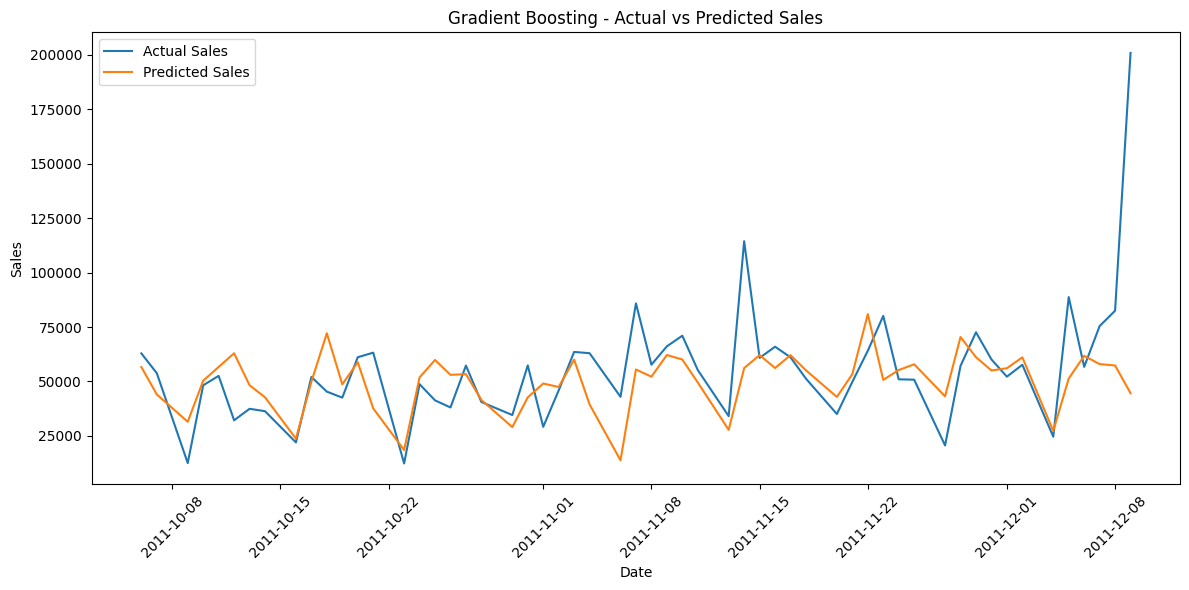

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"].iloc[split_index:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    df["date"].iloc[split_index:],
    y_pred,
    label="Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Gradient Boosting - Actual vs Predicted Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

day_of_week        0.189043
month              0.133579
lag_7              0.120000
lag_14             0.114993
lag_28             0.086891
lag_1              0.083844
rolling_mean_7     0.075264
is_weekend         0.072771
rolling_mean_14    0.056007
rolling_std_7      0.037728
day                0.029880
dtype: float64


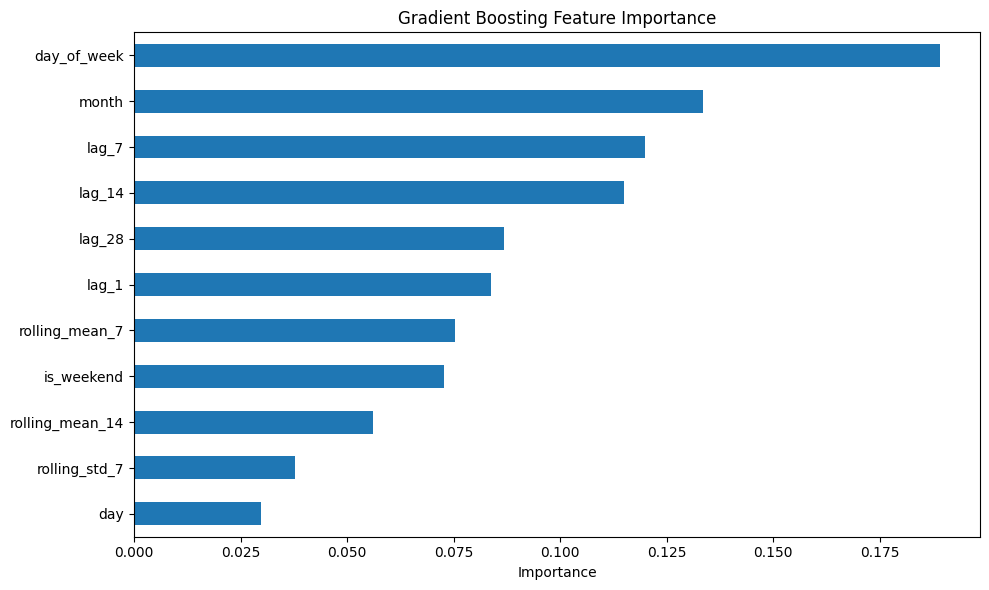

In [11]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind="barh")

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [13]:
joblib.dump(
    model,
    "./models/gradient_boosting_sales_model.pkl"
)

print("Gradient Boosting model saved successfully!")

Gradient Boosting model saved successfully!
